### Transactions in USD

In [1]:
# Import the required libraries
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
Tran_USD = pd.read_csv("../Datasets/Transactions_In_USD.csv")
Tran_USD.head()

,Region,Airtime top-up,Bill payment,Bulk disbursement,Cash-in,Cash-out,International remittance,Merchant payment,P2P transfer
0,Northern Africa,111347912,160953675,3333757,1526082743,959205511,1103342,311117024,7278491183
1,Eastern Africa,4247425201,60374210782,59957891032,151462435430,83841650916,9733075892,48326080634,230793170693
2,Middle Africa,2139854334,1083219883,991575739,29538801452,25017168623,1661727104,5423422967,17088573984
3,Southern Africa,116316047,177008755,116692333,1811089336,1691718062,103845296,352938600,1920232008
4,Western Africa,5343598265,3591008942,2775764022,84008344972,99482841202,12252986103,15236370743,134250636327


In [4]:
Tran_USD.info()
Tran_USD.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Region                    5 non-null      object
 1   Airtime top-up            5 non-null      int64 
 2   Bill payment              5 non-null      int64 
 3   Bulk disbursement         5 non-null      int64 
 4   Cash-in                   5 non-null      int64 
 5   Cash-out                  5 non-null      int64 
 6   International remittance  5 non-null      int64 
 7   Merchant payment          5 non-null      int64 
 8   P2P transfer              5 non-null      int64 
dtypes: int64(8), object(1)
memory usage: 488.0+ bytes


Region                      0
Airtime top-up              0
Bill payment                0
Bulk disbursement           0
Cash-in                     0
Cash-out                    0
International remittance    0
Merchant payment            0
P2P transfer                0
dtype: int64

In [5]:
Tran_USD.columns = Tran_USD.columns.str.lower().str.strip().str.replace(' ', '_')

In [6]:
target_columns = ['airtime_top-up', 'bill_payment', 'cash-in', 'cash-out']

In [ ]:
import os

# Update this to the exact absolute path to your folder
Saved_Plots = "/home/yaa_baby/Documents/PROJECTS/Momo_In_Africa/Saved_Plots"

# This safety check ensures Python verifies the folder exists before saving
if not os.path.exists(Saved_Plots):
    print(f"Warning: The directory {Saved_Plots} was not found. Creating it now.")
    os.makedirs(Saved_Plots, exist_ok=True)

Saved: /home/yaa_baby/Documents/PROJECTS/Momo_In_Africa/Saved_Plots/Tran_USD_airtime_top-up.png


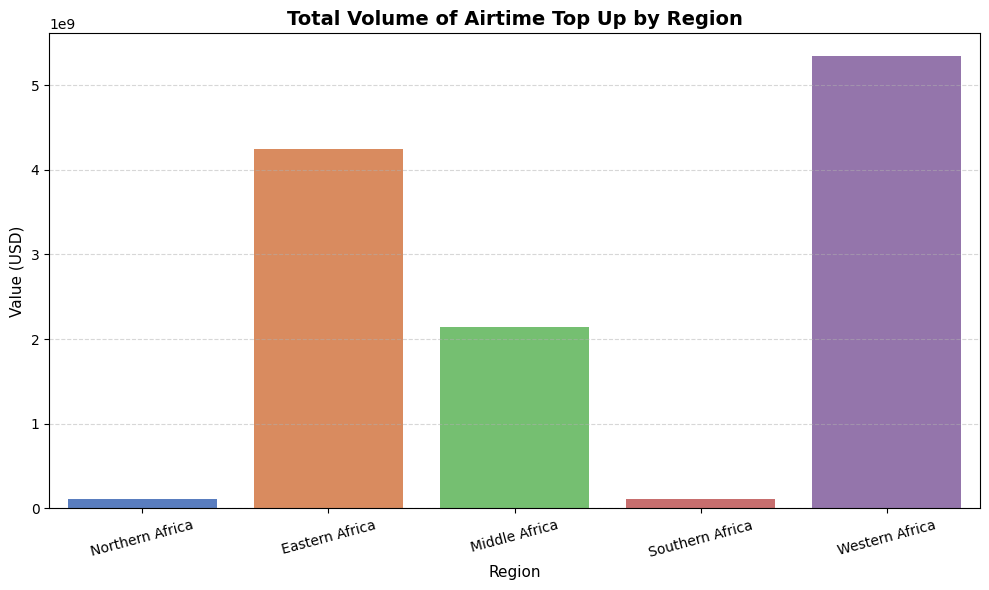

Saved: /home/yaa_baby/Documents/PROJECTS/Momo_In_Africa/Saved_Plots/Tran_USD_bill_payment.png


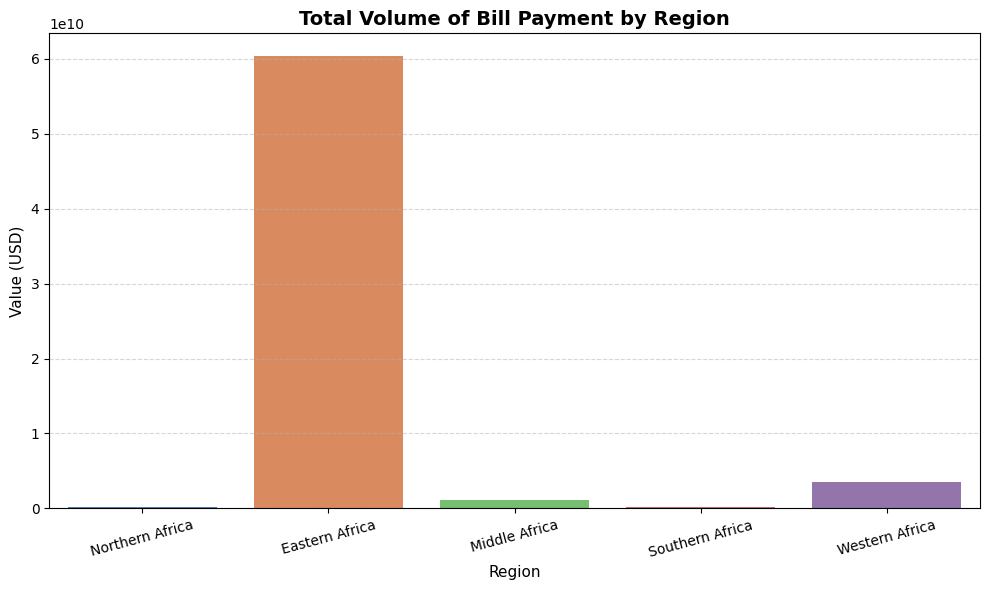

Saved: /home/yaa_baby/Documents/PROJECTS/Momo_In_Africa/Saved_Plots/Tran_USD_cash-in.png


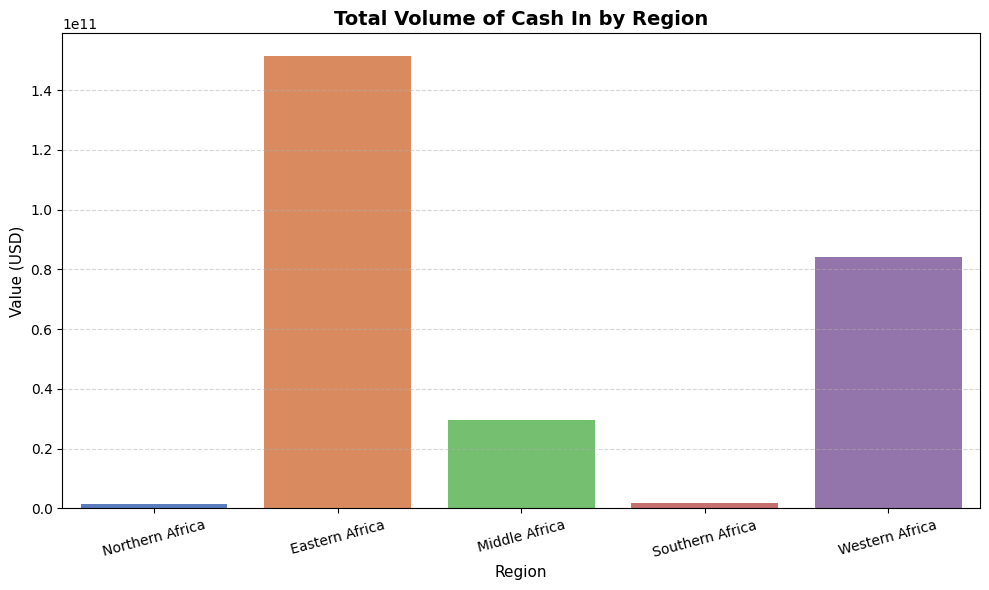

Saved: /home/yaa_baby/Documents/PROJECTS/Momo_In_Africa/Saved_Plots/Tran_USD_cash-out.png


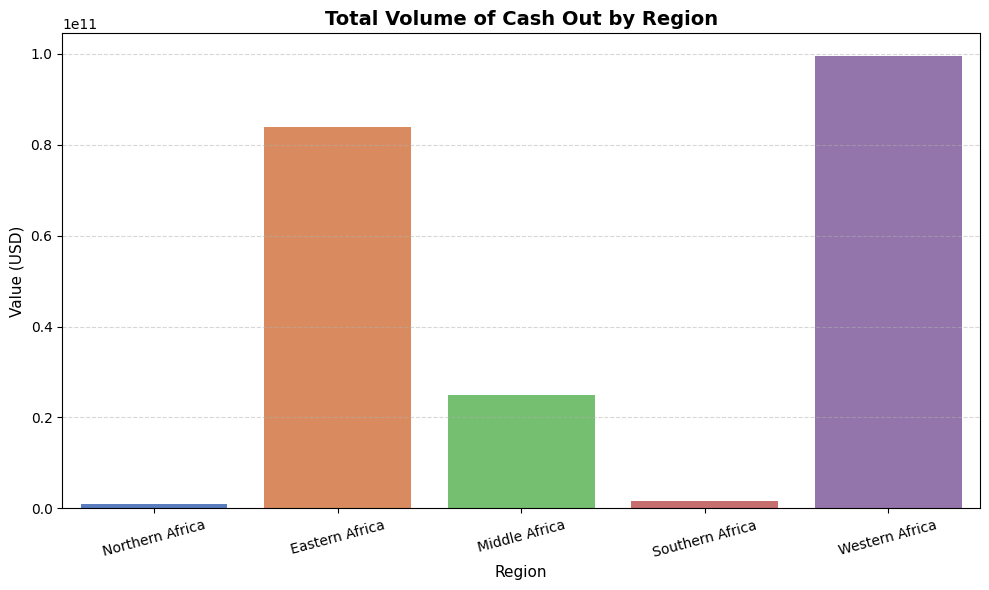

In [34]:
for col in target_columns:
    if col in Tran_USD.columns:
        plt.figure(figsize=(10, 6))
        
        # Using barplot instead of histplot to compare single totals cleanly
        ax = sns.barplot(
            data=Tran_USD,
            x='region',
            y=col,
            hue='region', # Keeps your beautiful regional color coding
            palette='muted',
            legend=False  # Legend is redundant here since region names are on the X-axis
        )
        
        # Clean up titles and labels
        clean_title = col.replace('_', ' ').replace('-', ' ').title()
        plt.title(f"Total Volume of {clean_title} by Region", fontsize=14, fontweight='bold')
        plt.xlabel("Region", fontsize=11)
        plt.ylabel("Value (USD)", fontsize=11)
        plt.grid(True, axis='y', linestyle="--", alpha=0.5) # Grid lines horizontal only
        
        plt.xticks(rotation=15)
        plt.tight_layout()
        
        # Save the file cleanly
        file_name = f"Tran_USD_{col}.png"
        save_path = os.path.join(Saved_Plots, file_name)
        plt.savefig(save_path, dpi=300)
        print(f"Saved: {save_path}")
        
        plt.show()
    else:
        print(f"Column '{col}' not found.")

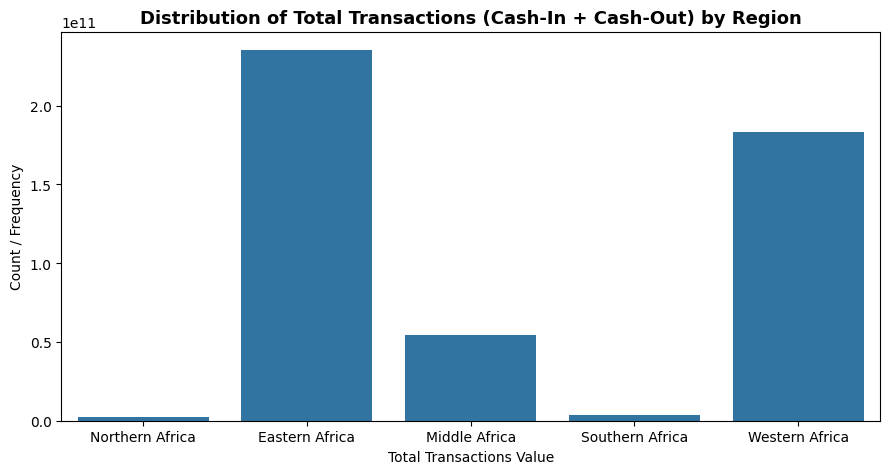

In [35]:
# 3. Create the 'total_transactions' column by adding cash-in and cash-out
# (Using .fillna(0) ensures that if one value is missing, it doesn't break the addition)
Tran_USD['total_transactions'] = Tran_USD['cash-in'].fillna(0) + Tran_USD['cash-out'].fillna(0)

# 4. Create a separate figure for the Total Transactions graph
plt.figure(figsize=(9, 5))

sns.barplot(
    data=Tran_USD,
    x='region',
    y='total_transactions'
)

# 5. Customize labels and appearance
plt.title("Distribution of Total Transactions (Cash-In + Cash-Out) by Region", fontsize=13, fontweight='bold')
plt.xlabel("Total Transactions Value")
plt.ylabel("Count / Frequency")


plt.tight_layout()

# Save the individual plot
plt.savefig("../Saved_Plots/Tran_USD_total_transactions.png", dpi=300)
plt.show()